# UrbanCart — Ecommerce Data Analysis

**Cleaning, integration, EDA, NumPy analytics, and chart generation**,
organized into four phases:

| Phase | Contents |
|---|---|
| **Phase 1** | SQL Exploration & Data Profiling (full SQL in `queries.sql`) |
| **Phase 2** | Data Cleaning & Integration → `data/processed/clean_orders.csv`, `clean_customers.csv` |
| **Phase 3** | Exploratory Data Analysis (distributions, cohort retention, market basket) |
| **Phase 4** | NumPy Analytics & Chart Generation (RFM/CLTV, regression, elasticity, Monte Carlo, recommender, forecasting) |

**Setup:** place `ecommerce.db`, `legacy_customers_export.csv`, and `product_catalog_2024.csv` in this same directory before running (these are the files "provided" alongside this assignment; not included in this repo).

**Data sources:** `ecommerce.db` (SQLite — source of truth), `legacy_customers_export.csv`,
`product_catalog_2024.csv`. All figures below are computed directly from this data.
The supplied *UrbanCart Master Specification* document was not used as a source of
numbers — it contains infrastructure claims and pre-stated metrics that don't
correspond to this dataset; the README data dictionary is the spec followed here.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from rapidfuzz import fuzz

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DB = "ecommerce.db"
LEGACY_CSV = "legacy_customers_export.csv"  # place alongside this notebook
CATALOG_CSV = "product_catalog_2024.csv"  # place alongside this notebook
PROCESSED = "data/processed"
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs("outputs", exist_ok=True)

NAVY = "#1E2761"; GOLD = "#E8B84B"; BLUE = "#2E5E8C"

con = sqlite3.connect(DB)

---
# Phase 1 — SQL Exploration & Data Profiling

Every query below also lives in `queries.sql` as standalone, runnable SQL
(`sqlite3 ecommerce.db < queries.sql`). Here we run the same statements
through `pandas.read_sql` so results display inline.

## 1.1 Schema & row counts

In [2]:
tables = ["customers", "products", "orders", "order_items", "reviews", "web_sessions"]
counts = pd.DataFrame({
    "table": tables,
    "n_rows": [pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", con)["n"][0] for t in tables],
})
counts

,table,n_rows
0,customers,2500
1,products,300
2,orders,9000
3,order_items,20362
4,reviews,4000
5,web_sessions,12000


In [3]:
schema = pd.read_sql("""
SELECT m.name AS table_name, p.name AS column_name, p.type
FROM sqlite_master m JOIN pragma_table_info(m.name) p
WHERE m.type = 'table' ORDER BY m.name, p.cid
""", con)
schema.head(15)

,table_name,column_name,type
0,customers,customer_id,INTEGER
1,customers,name,TEXT
2,customers,email,TEXT
3,customers,signup_date,TEXT
4,customers,city,TEXT
5,customers,country,TEXT
6,customers,age,INTEGER
7,customers,gender,TEXT
8,order_items,order_item_id,INTEGER
9,order_items,order_id,INTEGER


## 1.2 Date ranges & distinct categorical values

In [4]:
print(pd.read_sql("SELECT MIN(signup_date) AS earliest_signup, MAX(signup_date) AS latest_signup FROM customers", con).to_string(index=False))
print(pd.read_sql("SELECT MIN(order_date) AS earliest_order, MAX(order_date) AS latest_order FROM orders", con).to_string(index=False))
print("\nOrder statuses:", pd.read_sql("SELECT DISTINCT status FROM orders", con)["status"].tolist())
print("Payment methods:", pd.read_sql("SELECT DISTINCT payment_method FROM orders", con)["payment_method"].tolist())
print("Product categories:", pd.read_sql("SELECT DISTINCT category FROM products", con)["category"].tolist())

earliest_signup latest_signup
     2019-01-01    2024-06-30
     earliest_order        latest_order
2022-01-02 09:07:07 2024-12-31 23:58:14

Order statuses: ['cancelled', 'completed', 'pending', 'returned']
Payment methods: ['bank_transfer', 'debit_card', 'gift_card', 'paypal', 'credit_card']
Product categories: ['Electronics', 'Home & Kitchen', 'Apparel', 'Sports & Outdoors', 'Beauty & Health', 'Books & Media']


## 1.3 Data quality checks

In [5]:
dq = pd.read_sql("""
SELECT
    SUM(CASE WHEN city IS NULL THEN 1 ELSE 0 END) AS missing_city,
    SUM(CASE WHEN age IS NULL THEN 1 ELSE 0 END) AS missing_age,
    SUM(CASE WHEN gender IS NULL THEN 1 ELSE 0 END) AS missing_gender
FROM customers
""", con)
dq

,missing_city,missing_age,missing_gender
0,63,139,115


In [6]:
dup_emails = pd.read_sql("""
SELECT LOWER(TRIM(email)) AS email_norm, COUNT(*) AS n
FROM customers GROUP BY email_norm HAVING COUNT(*) > 1
""", con)
print("Duplicate customer emails:", len(dup_emails))

orphans = {
    "orphan_orders_bad_customer": pd.read_sql("SELECT COUNT(*) AS n FROM orders o LEFT JOIN customers c ON c.customer_id=o.customer_id WHERE c.customer_id IS NULL", con)["n"][0],
    "orphan_order_items_bad_order": pd.read_sql("SELECT COUNT(*) AS n FROM order_items oi LEFT JOIN orders o ON o.order_id=oi.order_id WHERE o.order_id IS NULL", con)["n"][0],
    "orphan_order_items_bad_product": pd.read_sql("SELECT COUNT(*) AS n FROM order_items oi LEFT JOIN products p ON p.product_id=oi.product_id WHERE p.product_id IS NULL", con)["n"][0],
}
print("Referential integrity (all should be 0):", orphans)

bad_ratings = pd.read_sql("SELECT COUNT(*) AS n FROM reviews WHERE rating < 1 OR rating > 5", con)["n"][0]
neg_qty = pd.read_sql("SELECT COUNT(*) AS n FROM order_items WHERE quantity < 0", con)["n"][0]
print(f"Out-of-range review ratings: {bad_ratings}   Negative-quantity order_items (returns): {neg_qty}")

Duplicate customer emails: 0
Referential integrity (all should be 0): {'orphan_orders_bad_customer': np.int64(0), 'orphan_order_items_bad_order': np.int64(0), 'orphan_order_items_bad_product': np.int64(0)}
Out-of-range review ratings: 41   Negative-quantity order_items (returns): 583


## 1.4 Outlier detection (product price, IQR method)

In [7]:
products_raw = pd.read_sql("SELECT * FROM products", con)
q1, q3 = products_raw["unit_price"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
outliers = products_raw[(products_raw["unit_price"] < lo) | (products_raw["unit_price"] > hi)]
print(f"IQR bounds: [{lo:.2f}, {hi:.2f}]  |  outliers: {len(outliers)}")
outliers[["product_id", "name", "category", "unit_price", "cost"]]

IQR bounds: [-969.30, 1741.17]  |  outliers: 3


,product_id,name,category,unit_price,cost
244,245,Throughout Personal Care,Beauty & Health,11506.5,104.23
249,250,Discover Haircare,Beauty & Health,8284.0,112.79
269,270,Environmental Non-Fiction,Books & Media,34872.0,252.13


---
# Phase 2 — Data Cleaning & Integration

Cleans `legacy_customers_export.csv` and `product_catalog_2024.csv`, reconciles
both against the DB, and builds the two integrated deliverables:
`data/processed/clean_customers.csv` and `data/processed/clean_orders.csv`.

## 2.1 Legacy customers — clean & reconcile

In [8]:
legacy = pd.read_csv(LEGACY_CSV)
legacy.columns = [c.strip() for c in legacy.columns]
n_raw = len(legacy)

for c in legacy.select_dtypes(include="object").columns:
    legacy[c] = legacy[c].astype(str).str.strip().replace({"nan": np.nan, "": np.nan})
legacy = legacy.dropna(how="all")

is_test = (
    legacy["EMAIL_ADDR"].astype(str).str.lower().str.contains("test", na=False)
    | legacy["Customer Name"].astype(str).str.lower().str.contains("test", na=False)
)
legacy = legacy[~is_test]

def parse_messy_date(s):
    if pd.isna(s):
        return pd.NaT
    s = str(s).strip()
    for fmt in ("%Y-%m-%d", "%B %d, %Y", "%m/%d/%Y", "%d-%b-%Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.to_datetime(s, errors="coerce")

legacy["name_clean"] = legacy["Customer Name"].astype(str).str.title().str.strip()
legacy["email_clean"] = legacy["EMAIL_ADDR"].astype(str).str.strip().str.lower()
legacy.loc[legacy["email_clean"].isin(["nan", "none", ""]), "email_clean"] = np.nan
legacy["signup_date_clean"] = legacy["Signup_Dt"].apply(parse_messy_date)
legacy["city_clean"] = legacy["Home City"].astype(str).str.strip().str.title()

exact_dup_mask = legacy["email_clean"].notna() & legacy.duplicated(subset=["email_clean"], keep="first")
n_exact_dupes = int(exact_dup_mask.sum())
legacy_deduped = legacy[~exact_dup_mask].copy()

print(f"raw={n_raw}  after cleaning/dedup={len(legacy_deduped)}  exact duplicate emails dropped={n_exact_dupes}")
legacy_deduped[["name_clean", "email_clean", "signup_date_clean", "city_clean"]].head()

/tmp/ipykernel_742/1863199770.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in legacy.select_dtypes(include="object").columns:


raw=1427  after cleaning/dedup=1377  exact duplicate emails dropped=48


,name_clean,email_clean,signup_date_clean,city_clean
0,Sarah Robinson,collinsjavier@example.org,2023-11-30,Chicago
1,Donald Todd,heathertran@example.com,2021-08-01,Toronto
2,Nathaniel Floyd,NaN,2021-05-27,Berlin
3,Sean Carter,dudleycody@example.com,2020-08-19,Singapore
4,Samuel Williams,jburke@example.org,2023-07-05,Melbourne


## 2.2 Product catalog — clean & reconcile by SKU

In [9]:
catalog = pd.read_csv(CATALOG_CSV)
catalog.columns = [c.strip() for c in catalog.columns]
catalog = catalog.rename(columns={
    "SKU": "product_id", "item_name": "name", "dept": "category",
    "list_price_usd": "unit_price", "supplier_cost": "cost", "in_stock_units": "stock_units",
})
catalog["unit_price"] = catalog["unit_price"].round(2)

db_ids = set(products_raw["product_id"])
overlap = sorted(set(catalog["product_id"]) & db_ids)
merged_price = catalog[catalog["product_id"].isin(overlap)].merge(
    products_raw[["product_id", "unit_price"]], on="product_id", suffixes=("_catalog", "_db")
)
merged_price["price_diff"] = (merged_price["unit_price_catalog"] - merged_price["unit_price_db"]).round(2)
mismatches = merged_price[merged_price["price_diff"].abs() > 0.01]
print(f"{len(mismatches)} of {len(overlap)} overlapping SKUs have a price mismatch, avg abs diff ${mismatches['price_diff'].abs().mean():.2f}")
catalog.to_csv(f"{PROCESSED}/../catalog_reference.csv", index=False) if False else None

253 of 255 overlapping SKUs have a price mismatch, avg abs diff $9.52


## 2.3 Build integrated `clean_orders.csv` and `clean_customers.csv`

In [10]:
customers = pd.read_sql("SELECT * FROM customers", con)
orders = pd.read_sql("SELECT * FROM orders", con, parse_dates=["order_date"])
order_items = pd.read_sql("SELECT * FROM order_items", con)
products = pd.read_sql("SELECT product_id, name AS product_name, category, unit_price AS list_price, cost FROM products", con)

# --- clean_orders.csv: order_items joined to orders + product metadata ---
oi = order_items.merge(orders, on="order_id", how="inner").merge(products, on="product_id", how="left")
oi["line_value"] = (oi["quantity"] * oi["unit_price"] * (1 - oi["discount"])).round(2)
oi["is_completed"] = (oi["status"] == "completed").astype(int)
oi = oi.dropna(subset=["order_id", "customer_id", "product_id"])
oi = oi[oi["quantity"] != 0]
oi["is_return"] = (oi["quantity"] < 0).astype(int)

clean_orders = oi[[
    "order_id", "customer_id", "order_date", "status", "payment_method",
    "product_id", "product_name", "category", "quantity", "unit_price", "discount",
    "line_value", "is_completed", "is_return"
]].sort_values(["order_date", "order_id"]).reset_index(drop=True)
clean_orders.to_csv(f"{PROCESSED}/clean_orders.csv", index=False)
print("clean_orders.csv:", clean_orders.shape)
clean_orders.head()

clean_orders.csv: (20362, 14)


,order_id,customer_id,order_date,status,payment_method,product_id,product_name,category,quantity,unit_price,discount,line_value,is_completed,is_return
0,8707,1236,2022-01-02 09:07:07,completed,debit_card,187,Artist Team Sport,Sports & Outdoors,1,127.57,0.05,121.19,1,0
1,621,765,2022-01-02 15:15:32,returned,gift_card,26,Agent Laptop,Electronics,1,259.69,0.00,259.69,0,0
2,621,765,2022-01-02 15:15:32,returned,gift_card,279,Scientist Non-Fiction,Books & Media,1,226.81,0.00,226.81,0,0
3,1139,1643,2022-01-03 03:39:21,pending,paypal,162,Do Team Sport,Sports & Outdoors,1,126.53,0.10,113.88,0,0
4,1139,1643,2022-01-03 03:39:21,pending,paypal,174,Social Cycling,Sports & Outdoors,2,864.84,0.00,1729.68,0,0


In [11]:
# --- clean_customers.csv: customers integrated with completed-order RFM aggregates ---
# Note: only positive-quantity lines count toward monetary/frequency (returns, which have
# negative quantity, are excluded here so a customer cannot show negative lifetime spend --
# they still appear in clean_orders.csv, tagged via is_return, just not netted into RFM).
completed_positive = oi[(oi["is_completed"] == 1) & (oi["quantity"] > 0)]
order_level = completed_positive.groupby(["customer_id", "order_id"]).agg(
    order_date=("order_date", "max"), order_value=("line_value", "sum")
).reset_index()

ref_date = order_level["order_date"].max() + pd.Timedelta(days=1)
cust_agg = order_level.groupby("customer_id").agg(
    recency_days=("order_date", lambda x: (ref_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("order_value", "sum"),
).reset_index()
cust_agg["monetary"] = cust_agg["monetary"].round(2)
cust_agg["avg_order_value"] = (cust_agg["monetary"] / cust_agg["frequency"]).round(2)

clean_customers = customers.merge(cust_agg, on="customer_id", how="left")

# Non-purchasers: recency = days since SIGNUP (maximally stale), not 0 (which would wrongly
# make a customer who never bought anything look like they just purchased today).
never_purchased = clean_customers["frequency"].isna()
clean_customers.loc[never_purchased, "recency_days"] = (
    ref_date - pd.to_datetime(clean_customers.loc[never_purchased, "signup_date"])
).dt.days
clean_customers["frequency"] = clean_customers["frequency"].fillna(0).astype(int)
clean_customers["monetary"] = clean_customers["monetary"].fillna(0)
clean_customers["avg_order_value"] = clean_customers["avg_order_value"].fillna(0)
clean_customers["has_purchased"] = (clean_customers["frequency"] > 0).astype(int)
clean_customers["name"] = clean_customers["name"].astype(str).str.strip()
clean_customers["email"] = clean_customers["email"].astype(str).str.strip().str.lower()
clean_customers["city"] = clean_customers["city"].astype(str).str.strip().str.title()

clean_customers.to_csv(f"{PROCESSED}/clean_customers.csv", index=False)
print("clean_customers.csv:", clean_customers.shape)
clean_customers.head()

clean_customers.csv: (2500, 13)


,customer_id,name,email,signup_date,city,country,age,gender,recency_days,frequency,monetary,avg_order_value,has_purchased
0,1,Allison Hill,donaldgarcia@example.net,2019-08-17,Sydney,Australia,63.0,M,373.0,2,1731.76,865.88,1
1,2,Angie Henderson,davisjesse@example.net,2023-02-25,Sydney,Australia,21.0,F,80.0,2,2567.68,1283.84,1
2,3,Cristian Santos,lrobinson@example.com,2021-10-31,Toronto,Canada,17.0,M,280.0,6,12657.74,2109.62,1
3,4,Abigail Shaffer,jpeterson@example.org,2020-03-27,Manchester,UK,53.0,M,1741.0,0,0.00,0.00,0
4,5,Gabrielle Davis,howardmaurice@example.com,2022-11-30,Chicago,USA,37.0,M,73.0,1,2723.52,2723.52,1


---
# Phase 3 — Exploratory Data Analysis

Distributions, order status mix, cohort retention, and market basket
affinity — using the integrated data from Phase 2.

## 3.1 Order status & payment method distribution

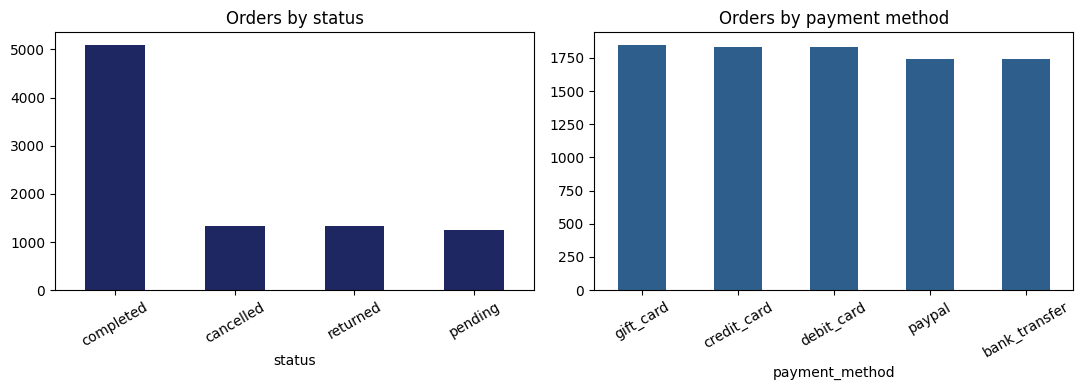

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
clean_orders.drop_duplicates("order_id")["status"].value_counts().plot(kind="bar", ax=axes[0], color=NAVY, title="Orders by status")
clean_orders.drop_duplicates("order_id")["payment_method"].value_counts().plot(kind="bar", ax=axes[1], color=BLUE, title="Orders by payment method")
for ax in axes: ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 3.2 Customer demographics

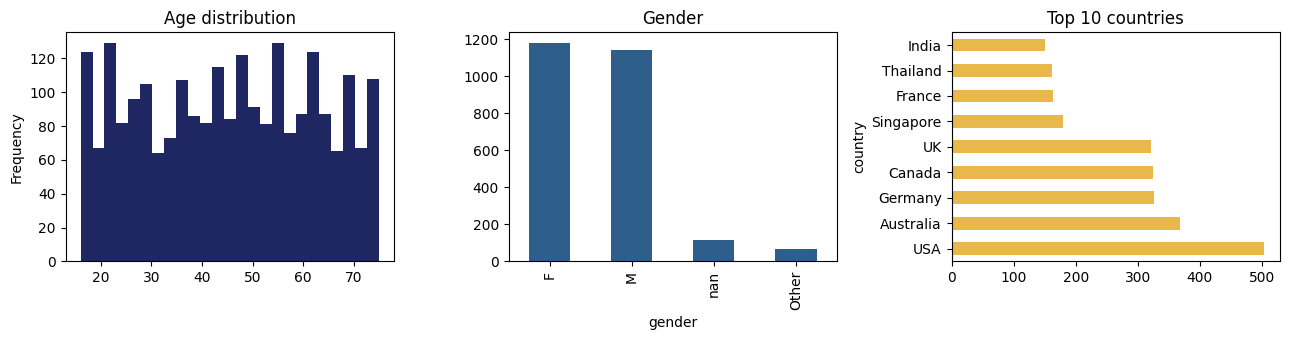

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
clean_customers["age"].dropna().plot(kind="hist", bins=25, ax=axes[0], color=NAVY, title="Age distribution")
clean_customers["gender"].value_counts(dropna=False).plot(kind="bar", ax=axes[1], color=BLUE, title="Gender")
clean_customers["country"].value_counts().head(10).plot(kind="barh", ax=axes[2], color=GOLD, title="Top 10 countries")
plt.tight_layout(); plt.show()

## 3.3 Order value & discount distributions

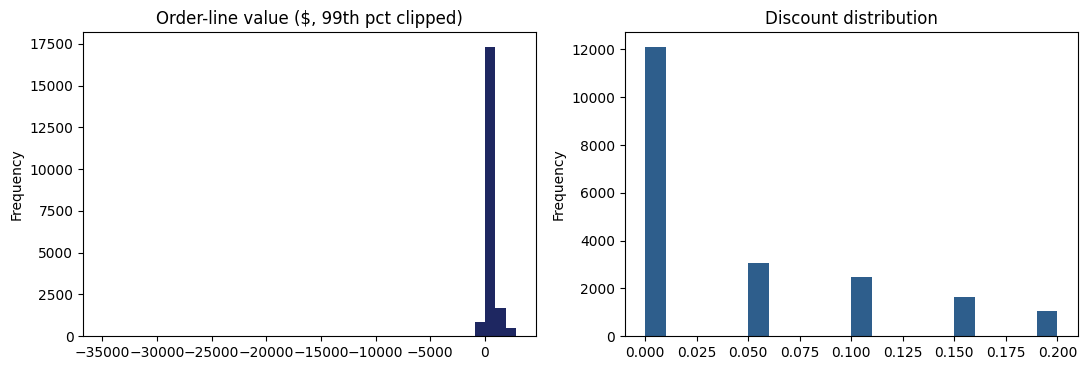

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
clean_orders["line_value"].clip(upper=clean_orders["line_value"].quantile(0.99)).plot(kind="hist", bins=40, ax=axes[0], color=NAVY, title="Order-line value ($, 99th pct clipped)")
clean_orders["discount"].plot(kind="hist", bins=20, ax=axes[1], color=BLUE, title="Discount distribution")
plt.tight_layout(); plt.show()

## 3.4 Monthly cohort retention

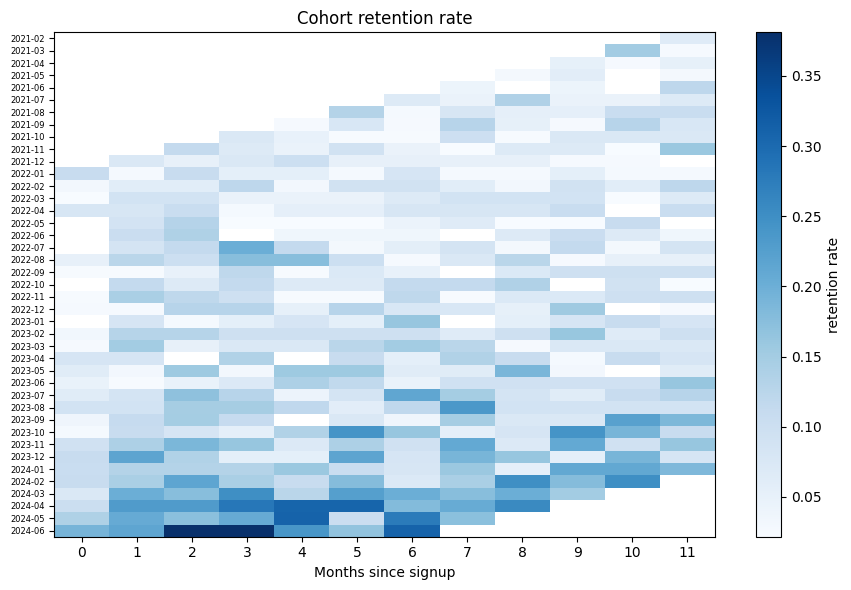

month_offset
0     0.0698
1     0.1099
2     0.1275
3     0.1196
4     0.0977
5     0.1036
6     0.0963
7     0.1054
8     0.0885
9     0.0887
10    0.0974
11    0.0882
Name: retention_rate, dtype: float64

In [15]:
cohort_q = """
WITH cohort AS (
    SELECT customer_id, strftime('%Y-%m', signup_date) AS cohort_month FROM customers
),
activity AS (
    SELECT o.customer_id, strftime('%Y-%m', o.order_date) AS order_month
    FROM orders o WHERE o.status = 'completed'
),
joined AS (
    SELECT c.cohort_month, a.customer_id,
           (CAST(strftime('%Y', a.order_month || '-01') AS INT) - CAST(strftime('%Y', c.cohort_month || '-01') AS INT)) * 12
           + (CAST(strftime('%m', a.order_month || '-01') AS INT) - CAST(strftime('%m', c.cohort_month || '-01') AS INT)) AS month_offset
    FROM cohort c JOIN activity a ON a.customer_id = c.customer_id
)
SELECT cohort_month, month_offset, COUNT(DISTINCT customer_id) AS active_customers
FROM joined WHERE month_offset BETWEEN 0 AND 11
GROUP BY cohort_month, month_offset ORDER BY cohort_month, month_offset;
"""
cohort_df = pd.read_sql(cohort_q, con)
cohort_size = pd.read_sql("SELECT strftime('%Y-%m', signup_date) AS cohort_month, COUNT(*) AS cohort_size FROM customers GROUP BY cohort_month", con)
cohort_df = cohort_df.merge(cohort_size, on="cohort_month")
cohort_df["retention_rate"] = (cohort_df["active_customers"] / cohort_df["cohort_size"]).round(4)
pivot = cohort_df.pivot(index="cohort_month", columns="month_offset", values="retention_rate")
pivot.to_csv("outputs/cohort_retention_matrix.csv")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index, fontsize=6)
ax.set_xlabel("Months since signup"); ax.set_title("Cohort retention rate")
plt.colorbar(im, label="retention rate"); plt.tight_layout(); plt.show()

avg_curve = cohort_df.groupby("month_offset")["retention_rate"].mean().round(4)
avg_curve

## 3.5 Market basket & category affinity

In [16]:
basket_q = """
WITH items AS (SELECT order_id, product_id FROM order_items WHERE quantity > 0),
pairs AS (SELECT a.product_id AS product_a, b.product_id AS product_b, a.order_id FROM items a JOIN items b ON a.order_id=b.order_id AND a.product_id<b.product_id),
pair_counts AS (SELECT product_a, product_b, COUNT(DISTINCT order_id) AS pair_orders FROM pairs GROUP BY product_a, product_b),
total_orders AS (SELECT COUNT(DISTINCT order_id) AS n FROM items),
product_order_counts AS (SELECT product_id, COUNT(DISTINCT order_id) AS orders_with_product FROM items GROUP BY product_id)
SELECT pc.product_a, pc.product_b, pc.pair_orders,
    ROUND(CAST(pc.pair_orders AS FLOAT)/t.n, 5) AS support,
    ROUND((CAST(pc.pair_orders AS FLOAT)/t.n) / ((CAST(pa.orders_with_product AS FLOAT)/t.n)*(CAST(pb.orders_with_product AS FLOAT)/t.n)), 4) AS lift
FROM pair_counts pc JOIN total_orders t
JOIN product_order_counts pa ON pa.product_id=pc.product_a
JOIN product_order_counts pb ON pb.product_id=pc.product_b
WHERE pc.pair_orders >= 3 ORDER BY lift DESC LIMIT 15;
"""
basket = pd.read_sql(basket_q, con)
basket.to_csv("outputs/market_basket_top_pairs.csv", index=False)
basket

,product_a,product_b,pair_orders,support,lift
0,201,268,4,0.00045,10.4750
1,1,60,5,0.00056,10.0872
2,4,163,4,0.00045,9.7901
3,48,294,4,0.00045,9.4525
4,99,252,4,0.00045,9.0608
5,44,273,3,0.00034,8.9990
6,55,61,4,0.00045,8.9808
7,73,98,4,0.00045,8.8515
8,188,201,3,0.00034,8.6832
9,113,247,4,0.00045,8.5705


---
# Phase 4 — NumPy Analytics & Chart Generation

RFM segmentation, CLTV, closed-form OLS regression, price elasticity,
Monte Carlo simulation, a from-scratch recommendation engine, and revenue
forecasting — all implemented with `numpy`, not black-box ML libraries.

## 4.1 RFM segmentation

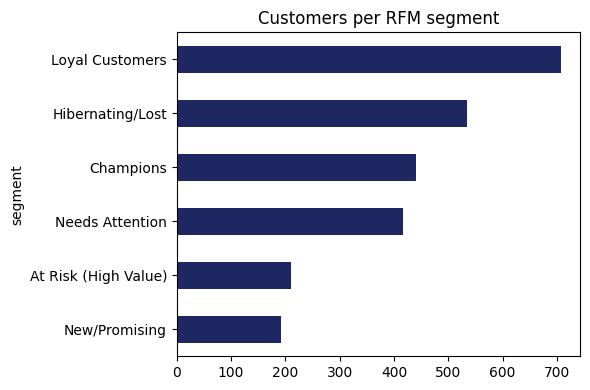

,n,avg_monetary
segment,,
Loyal Customers,707,3327.93
Hibernating/Lost,535,280.60
Champions,441,6934.79
Needs Attention,416,2878.77
At Risk (High Value),210,4192.84
New/Promising,191,1350.83


In [17]:
rfm = clean_customers.copy()
rfm["R_score"] = pd.qcut(rfm["recency_days"].rank(method="first"), 5, labels=[5,4,3,2,1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)

def segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4: return "Champions"
    if r >= 3 and f >= 3: return "Loyal Customers"
    if r >= 4 and f <= 2: return "New/Promising"
    if r <= 2 and f >= 4: return "At Risk (High Value)"
    if r <= 2 and f <= 2 and m <= 2: return "Hibernating/Lost"
    return "Needs Attention"

rfm["segment"] = rfm.apply(segment, axis=1)
seg_summary = rfm.groupby("segment").agg(n=("customer_id","count"), avg_monetary=("monetary","mean")).round(2).sort_values("n", ascending=False)
seg_summary["n"].sort_values().plot(kind="barh", figsize=(6,4), color=NAVY, title="Customers per RFM segment")
plt.tight_layout(); plt.show()
seg_summary

## 4.2 Customer Lifetime Value

margin rate=48.832%  mean CLTV=$1,916.85  median CLTV=$990.27


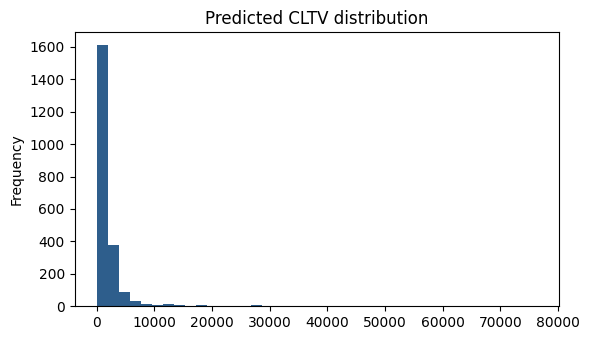

In [18]:
products_db = pd.read_sql("SELECT unit_price, cost FROM products", con)
margin_rate = float(((products_db["unit_price"] - products_db["cost"]) / products_db["unit_price"]).mean())
span_years = max((clean_orders["order_date"].max() - clean_orders["order_date"].min()).days / 365.25, 0.5)

active = rfm[rfm["frequency"] > 0].copy()
active["purchase_freq_per_year"] = active["frequency"] / span_years
active["tenure_years"] = ((pd.to_datetime(clean_orders["order_date"].max()) - pd.to_datetime(active["signup_date"])).dt.days / 365.25).clip(lower=0.25)
active["predicted_cltv"] = (active["avg_order_value"] * active["purchase_freq_per_year"] * active["tenure_years"] * margin_rate).round(2)

print(f"margin rate={margin_rate:.3%}  mean CLTV=${active['predicted_cltv'].mean():,.2f}  median CLTV=${active['predicted_cltv'].median():,.2f}")
active["predicted_cltv"].plot(kind="hist", bins=40, figsize=(6,3.5), color=BLUE, title="Predicted CLTV distribution")
plt.tight_layout(); plt.show()

## 4.3 OLS regression (closed-form, numpy)

In [19]:
def ols_fit(X, y):
    X1 = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    y_hat = X1 @ beta
    ss_res = np.sum((y - y_hat) ** 2); ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    n, k = X1.shape
    sigma2 = ss_res / (n - k)
    se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X1.T @ X1)))
    return {"beta": beta, "t_stats": beta / se, "r2": r2, "n": n}

reg_df = active.dropna(subset=["age"])
X = reg_df[["age", "frequency", "recency_days"]].to_numpy(dtype=float)
y = reg_df["monetary"].to_numpy(dtype=float)
fit = ols_fit(X, y)
pd.DataFrame({"beta": fit["beta"], "t_stat": fit["t_stats"]}, index=["intercept","age","frequency","recency_days"])

,beta,t_stat
intercept,9.257450,0.014983
age,-8.586273,-0.933660
frequency,1713.680983,12.620257
recency_days,0.220139,0.349247


## 4.4 Price elasticity of demand (log-log OLS by category)

In [20]:
eq = """
SELECT p.category, oi.unit_price, oi.discount, oi.quantity
FROM order_items oi JOIN products p ON p.product_id=oi.product_id JOIN orders o ON o.order_id=oi.order_id
WHERE o.status='completed' AND oi.quantity>0 AND oi.unit_price>0
"""
edf = pd.read_sql(eq, con)
edf["eff_price"] = edf["unit_price"] * (1 - edf["discount"])
edf["log_price"] = np.log(edf["eff_price"]); edf["log_qty"] = np.log(edf["quantity"])

elasticity = {}
for cat, g in edf.groupby("category"):
    if len(g) < 30: continue
    f = ols_fit(g[["log_price"]].to_numpy(float), g["log_qty"].to_numpy(float))
    elasticity[cat] = {"elasticity": round(float(f["beta"][1]),4), "t_stat": round(float(f["t_stats"][1]),3)}
pd.DataFrame(elasticity).T

,elasticity,t_stat
Apparel,0.0115,1.400
Beauty & Health,-0.0050,-0.646
Books & Media,0.0051,0.846
Electronics,-0.0096,-1.121
Home & Kitchen,-0.0121,-1.320
Sports & Outdoors,-0.0003,-0.032


## 4.5 Monte Carlo revenue simulation

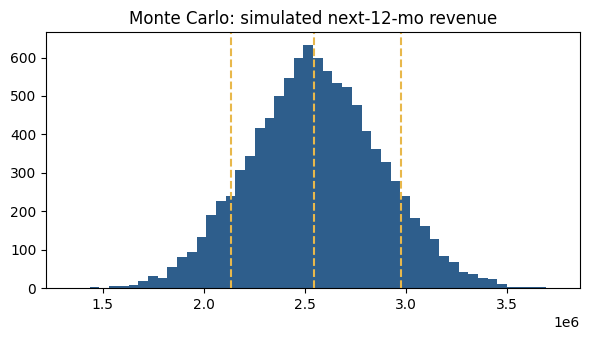

P10=$2,132,708  P50=$2,547,400  P90=$2,977,445


In [21]:
rng = np.random.default_rng(42)
monthly = pd.read_sql("SELECT strftime('%Y-%m', o.order_date) AS month, SUM(oi.quantity*oi.unit_price*(1-oi.discount)) AS revenue FROM orders o JOIN order_items oi ON oi.order_id=o.order_id WHERE o.status='completed' GROUP BY month ORDER BY month", con)
monthly_rev = monthly["revenue"].iloc[1:-1]
mu, sigma = float(monthly_rev.mean()), float(monthly_rev.std(ddof=1))
sims = np.clip(rng.normal(mu, sigma, size=(10000, 12)), 0, None)
annual_totals = sims.sum(axis=1)

plt.figure(figsize=(6,3.5))
plt.hist(annual_totals, bins=50, color=BLUE)
for p in [10,50,90]: plt.axvline(np.percentile(annual_totals,p), color=GOLD, linestyle="--")
plt.title("Monte Carlo: simulated next-12-mo revenue"); plt.tight_layout(); plt.show()
print(f"P10=${np.percentile(annual_totals,10):,.0f}  P50=${np.percentile(annual_totals,50):,.0f}  P90=${np.percentile(annual_totals,90):,.0f}")

## 4.6 Recommendation engine (item-based cosine similarity)

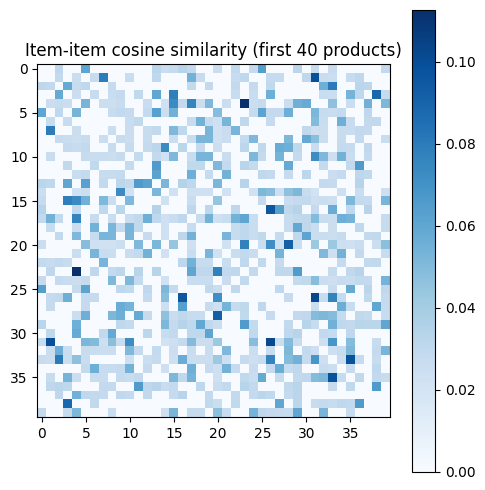

In [22]:
purch = pd.read_sql("SELECT o.customer_id, oi.product_id, SUM(oi.quantity) AS qty FROM orders o JOIN order_items oi ON oi.order_id=o.order_id WHERE o.status='completed' AND oi.quantity>0 GROUP BY o.customer_id, oi.product_id", con)
custs = sorted(purch["customer_id"].unique()); prods = sorted(purch["product_id"].unique())
ci = {c:i for i,c in enumerate(custs)}; pi = {p:i for i,p in enumerate(prods)}
M = np.zeros((len(custs), len(prods)))
for r in purch.itertuples(): M[ci[r.customer_id], pi[r.product_id]] = r.qty
Mb = (M > 0).astype(float)
norms = np.linalg.norm(Mb, axis=0); norms[norms==0] = 1e-9
sim = (Mb.T @ Mb) / np.outer(norms, norms)
np.fill_diagonal(sim, 0)

plt.figure(figsize=(5,5))
plt.imshow(sim[:40,:40], cmap="Blues"); plt.title("Item-item cosine similarity (first 40 products)")
plt.colorbar(); plt.tight_layout(); plt.show()

## 4.7 Revenue forecasting (Holt's linear smoothing + OLS trend, numpy)

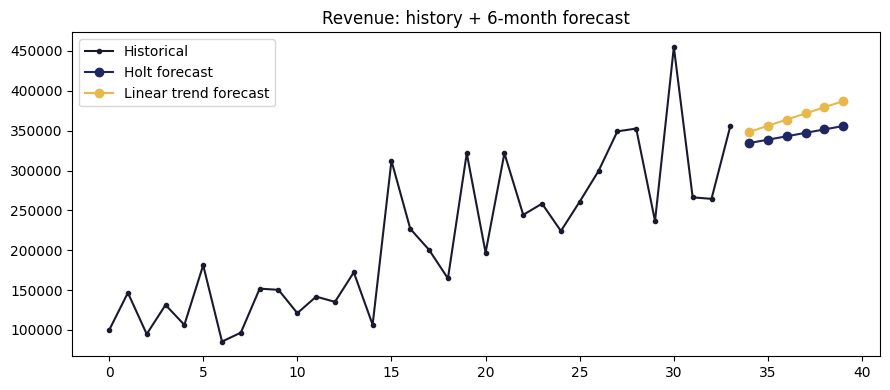

In [23]:
def holt_linear(y, alpha=0.4, beta=0.2, n_forecast=6):
    level = np.zeros(len(y)); trend = np.zeros(len(y))
    level[0] = y[0]; trend[0] = y[1]-y[0] if len(y)>1 else 0
    for t in range(1, len(y)):
        level[t] = alpha*y[t] + (1-alpha)*(level[t-1]+trend[t-1])
        trend[t] = beta*(level[t]-level[t-1]) + (1-beta)*trend[t-1]
    return np.array([level[-1] + (h+1)*trend[-1] for h in range(n_forecast)])

y = monthly_rev.to_numpy(dtype=float)
holt_fc = holt_linear(y, n_forecast=6)
t = np.arange(len(y)); Xt = np.column_stack([np.ones(len(t)), t])
beta_lin, *_ = np.linalg.lstsq(Xt, y, rcond=None)
lin_fc = beta_lin[0] + beta_lin[1]*np.arange(len(y), len(y)+6)

plt.figure(figsize=(9,4))
plt.plot(range(len(y)), y, label="Historical", color="#1A1A2E", marker="o", markersize=3)
plt.plot(range(len(y), len(y)+6), holt_fc, label="Holt forecast", color=NAVY, marker="o")
plt.plot(range(len(y), len(y)+6), lin_fc, label="Linear trend forecast", color=GOLD, marker="o")
plt.legend(); plt.title("Revenue: history + 6-month forecast"); plt.tight_layout(); plt.show()

con.close()

---
## Done

All four phases executed against the live database and raw CSVs. Processed
datasets are in `data/processed/`; the full SQL listing is in `queries.sql`;
detailed write-ups are in `report.pdf` and `executive_summary.pdf`.